# LightGBM Optuna Centralisé — Pipeline complet avec timing MLflow

Notebook unique qui fusionne le preprocessing commun et l'entraînement LightGBM avec **optimisation Optuna**, tracking MLflow et mesure systématique du temps de chaque étape.

Sert de **référence centralisée tunée** pour la comparaison avec la version distribuée (PySpark + SynapseML sur Dataproc). Conditions volontairement alignées : même dataset à sa taille réelle (pas de réduction mémoire), même split temporel, même métrique principale (AUC-PR), mêmes features.

**Architecture MLflow :**
- Un seul run wrappe l'intégralité du notebook → tous les timings et metrics sont attachés au même `run_id`
- Un context manager `timed_stage()` logge automatiquement `time_<stage>_s` dans MLflow
- Mémoire process (RSS) loggée à chaque jalon clé
- Tag `approach=centralized_optuna` pour matcher avec `approach=distributed_dataproc` côté Spark

**Pipeline :**
1. Chargement + merge (train_transaction × train_identity)
2. Drop colonnes >90% NaN et quasi-constantes
3. Feature engineering commun : normalisation D, features temporelles, TransactionAmt, email, M*, DeviceInfo
4. Feature engineering avancé : UID client, frequency encoding, group aggregations, features dérivées
5. Label encoding + imputation -999 + split temporel 60/20/20
6. Optimisation Optuna (TPE + MedianPruner, baseline Kaggle injecté comme prior)
7. Entraînement final LightGBM avec hyperparamètres optimisés
8. Réentraînement sur 100% + soumission Kaggle

## 1. Imports & configuration

In [1]:
!pip install mlflow psutil optuna -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 78.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 59.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 45.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 891.5/891.5 kB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 11.9 MB/s eta 0:00:00


In [2]:
import os, gc, time, warnings, psutil
from contextlib import contextmanager
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
    f1_score, recall_score,
)
import lightgbm as lgb
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner

import mlflow
import mlflow.lightgbm

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
pd.set_option('display.max_columns', 100)

SEED         = 42
N_TRIALS_LGB = 60  # nombre d'essais Optuna ; ajuster selon temps disponible (min recommandé : 30)

DATA_DIR   = '/kaggle/input/datasets/ayushcl/ieee-fraud-detection-zip'
OUT_DIR    = '/kaggle/working/'
MLFLOW_DIR = f'{OUT_DIR}/mlruns'

PROC = psutil.Process(os.getpid())

print(os.listdir(DATA_DIR))

['sample_submission.csv', 'test_identity.csv', 'train_identity.csv', 'test_transaction.csv', 'train_transaction.csv']


## 2. MLflow setup + helpers de timing

Le run MLflow est démarré ici et reste actif jusqu'à la dernière cellule. Le context manager `timed_stage` mesure wall-time + RAM et logge automatiquement `time_<stage>_s` et `mem_after_<stage>_gb`.

In [3]:
mlflow.set_tracking_uri(f'file:{MLFLOW_DIR}')
mlflow.set_experiment('ieee_fraud_lgbm')

# Sécurité : ferme un run resté ouvert d'une exécution précédente
if mlflow.active_run() is not None:
    mlflow.end_run()

print(f"Tracking URI : {mlflow.get_tracking_uri()}")
print(f"Experiment   : {mlflow.get_experiment_by_name('ieee_fraud_lgbm').name}")

2026/05/18 22:04:35 INFO mlflow.tracking.fluent: Experiment with name 'ieee_fraud_lgbm' does not exist. Creating a new experiment.


Tracking URI : file:/kaggle/working//mlruns
Experiment   : ieee_fraud_lgbm


In [4]:
TIMINGS = {}
MEMORY  = {}

def log_memory(label):
    """Logge la RAM process actuelle dans MLflow + dict local."""
    rss_gb = PROC.memory_info().rss / 1024**3
    MEMORY[label] = rss_gb
    if mlflow.active_run() is not None:
        mlflow.log_metric(f'mem_{label}_gb', rss_gb)
    return rss_gb

@contextmanager
def timed_stage(name):
    """Mesure le wall-time d'un bloc, logge dans MLflow et affiche."""
    t0 = time.time()
    rss_before = PROC.memory_info().rss / 1024**3
    print(f'[{name}] start ... (RAM : {rss_before:.2f} GB)')
    try:
        yield
    finally:
        elapsed = time.time() - t0
        rss_after = PROC.memory_info().rss / 1024**3
        TIMINGS[name] = elapsed
        MEMORY[f'after_{name}'] = rss_after
        if mlflow.active_run() is not None:
            mlflow.log_metric(f'time_{name}_s', elapsed)
            mlflow.log_metric(f'mem_after_{name}_gb', rss_after)
        print(f'[{name}] done in {elapsed:.1f}s (RAM : {rss_after:.2f} GB, Δ {rss_after-rss_before:+.2f} GB)')

In [5]:
# Démarrage du run principal — reste actif jusqu'à la cellule finale
run = mlflow.start_run(run_name='lgbm_centralized_optuna')
RUN_ID = run.info.run_id
print(f'Run actif : {RUN_ID}')

mlflow.set_tags({
    'approach'   : 'centralized_optuna',
    'framework'  : 'lightgbm',
    'tuning'     : 'optuna_tpe',
    'dataset'    : 'ieee-cis',
    'split'      : 'temporal_60_20_20',
    'imputation' : 'sentinel_-999',
    'env'        : 'kaggle_single_node',
    'machine'    : 'kaggle_p100_16gb',
})

log_memory('start')

Run actif : 21494a26a8ae49d1a03f852c697b15b6


0.3600730895996094

## 3. Chargement + merge

In [6]:
with timed_stage('load_merge'):
    train_tx = pd.read_csv(f'{DATA_DIR}/train_transaction.csv')
    train_id = pd.read_csv(f'{DATA_DIR}/train_identity.csv')
    test_tx  = pd.read_csv(f'{DATA_DIR}/test_transaction.csv')
    test_id  = pd.read_csv(f'{DATA_DIR}/test_identity.csv')

    # test_identity utilise '-' au lieu de '_'
    test_id.columns = [c.replace('-', '_') for c in test_id.columns]

    train       = train_tx.merge(train_id, how='left', on='TransactionID')
    test_kaggle = test_tx.merge(test_id,   how='left', on='TransactionID')
    del train_tx, train_id, test_tx, test_id; gc.collect()

mem_train_mb = train.memory_usage(deep=True).sum() / 1024**2
mem_test_mb  = test_kaggle.memory_usage(deep=True).sum() / 1024**2

mlflow.log_params({
    'raw_train_rows' : len(train),
    'raw_test_rows'  : len(test_kaggle),
    'raw_train_cols' : train.shape[1],
    'raw_test_cols'  : test_kaggle.shape[1],
})
mlflow.log_metrics({
    'mem_train_mb_raw' : mem_train_mb,
    'mem_test_mb_raw'  : mem_test_mb,
})

print(f'Train       : {train.shape}       | mémoire : {mem_train_mb:.0f} MB')
print(f'Test Kaggle : {test_kaggle.shape} | mémoire : {mem_test_mb:.0f} MB')
print(f'Fraud rate  : {train.isFraud.mean():.4f}')

[load_merge] start ... (RAM : 0.36 GB)
[load_merge] done in 52.4s (RAM : 5.16 GB, Δ +4.80 GB)
Train       : (590540, 434)       | mémoire : 2514 MB
Test Kaggle : (506691, 433) | mémoire : 2164 MB
Fraud rate  : 0.0350


## 4. Drop des colonnes >90% NaN et quasi-constantes

In [7]:
with timed_stage('drop_columns'):
    missing_pct = train.isnull().mean()
    cols_drop_nan = missing_pct[missing_pct > 0.90].index.tolist()
    train.drop(columns=cols_drop_nan, inplace=True)
    test_kaggle.drop(columns=[c for c in cols_drop_nan if c in test_kaggle.columns], inplace=True)

    near_const = []
    for c in train.columns:
        if c in ('isFraud', 'TransactionID'):
            continue
        if train[c].value_counts(dropna=False, normalize=True).iloc[0] > 0.99:
            near_const.append(c)
    train.drop(columns=near_const, inplace=True)
    test_kaggle.drop(columns=[c for c in near_const if c in test_kaggle.columns], inplace=True)

print(f'{len(cols_drop_nan)} colonnes >90% NaN droppées')
print(f'{len(near_const)} colonnes quasi-constantes droppées')
print(f'Shape : train {train.shape} | test {test_kaggle.shape}')

mlflow.log_params({
    'cols_dropped_high_nan'   : len(cols_drop_nan),
    'cols_dropped_near_const' : len(near_const),
})

[drop_columns] start ... (RAM : 5.16 GB)
[drop_columns] done in 7.4s (RAM : 5.02 GB, Δ -0.14 GB)
12 colonnes >90% NaN droppées
15 colonnes quasi-constantes droppées
Shape : train (590540, 407) | test (506691, 406)


## 5. Feature engineering commun

In [8]:
with timed_stage('fe_common'):
    # 5.1 Normalisation D (anti-drift temporel)
    for i in range(1, 16):
        col = f'D{i}'
        if col not in train.columns or i in (1, 2, 3, 5, 9):
            continue
        train[col]       = (train[col]       - train['TransactionDT']       / np.float32(86400)).astype(np.float32)
        test_kaggle[col] = (test_kaggle[col] - test_kaggle['TransactionDT'] / np.float32(86400)).astype(np.float32)

    # 5.2 Features temporelles
    START = pd.Timestamp('2017-12-01')
    for df in [train, test_kaggle]:
        dt = df['TransactionDT'].apply(lambda s: START + pd.Timedelta(seconds=s))
        df['DT_hour']    = dt.dt.hour.astype(np.int8)
        df['DT_weekday'] = dt.dt.weekday.astype(np.int8)
        df['DT_day']     = dt.dt.day.astype(np.int8)
        df['DT_month']   = dt.dt.month.astype(np.int8)
        df['DT_M']       = ((dt.dt.year - 2017) * 12 + dt.dt.month).astype(np.int8)

    # 5.3 TransactionAmt
    for df in [train, test_kaggle]:
        df['TransactionAmt_log']   = np.log1p(df['TransactionAmt']).astype(np.float32)
        df['TransactionAmt_cents'] = (df['TransactionAmt'] - np.floor(df['TransactionAmt'])).astype(np.float32)

    # 5.4 Email
    emails = {
        'gmail.com':'google',   'gmail':'google',
        'yahoo.com':'yahoo',    'yahoo.fr':'yahoo',
        'hotmail.com':'microsoft', 'hotmail.fr':'microsoft',
        'outlook.com':'microsoft', 'live.com':'microsoft', 'msn.com':'microsoft',
        'aol.com':'aol',
        'icloud.com':'apple', 'me.com':'apple', 'mac.com':'apple',
        'anonymous.com':'anonymous'
    }
    for df in [train, test_kaggle]:
        for c in ['P_emaildomain', 'R_emaildomain']:
            df[f'{c}_bin']    = df[c].map(emails).fillna('other')
            df[f'{c}_suffix'] = df[c].astype(str).str.rsplit('.', n=1).str[-1]
        df['email_check'] = ((df['P_emaildomain'] == df['R_emaildomain']) &
                            (df['P_emaildomain'].notna())).astype(np.int8)

    # 5.5 M columns
    M_cols = [c for c in ['M1','M2','M3','M5','M6','M7','M8','M9'] if c in train.columns]
    for df in [train, test_kaggle]:
        df['M_na'] = df[M_cols].isna().sum(axis=1).astype(np.int8)
        mm = df[M_cols].replace({'T': 1, 'F': 0})
        df['M_sum'] = pd.to_numeric(mm.stack(), errors='coerce').unstack().sum(axis=1).astype(np.int8)

    # 5.6 DeviceInfo / id_30 / id_31 split
    def split_device(s):
        s = str(s).lower() if pd.notna(s) else 'unknown'
        dev = ''.join(ch for ch in s if ch.isalpha()) or 'unknown'
        ver = ''.join(ch for ch in s if ch.isnumeric()) or '0'
        return dev, ver

    for df in [train, test_kaggle]:
        for col in ['DeviceInfo', 'id_30', 'id_31']:
            if col not in df.columns:
                continue
            parts = df[col].apply(split_device)
            df[f'{col}_device']  = parts.apply(lambda x: x[0])
            df[f'{col}_version'] = parts.apply(lambda x: x[1])

print(f'Shape après FE commun : train {train.shape} | test {test_kaggle.shape}')

[fe_common] start ... (RAM : 5.02 GB)
[fe_common] done in 27.5s (RAM : 5.38 GB, Δ +0.36 GB)
Shape après FE commun : train (590540, 427) | test (506691, 426)


## 6. Feature engineering avancé (UID + agrégations)

UID client (`card1 + addr1 + D1n`), frequency encoding, group aggregations par UID et features dérivées (ratio, z-score, time delta).

In [9]:
with timed_stage('fe_advanced'):
    # 6.1 UID
    for df in [train, test_kaggle]:
        df['day'] = df['TransactionDT'] // (24 * 60 * 60)
        df['D1n'] = df['day'] - df['D1']
        df['uid'] = (df['card1'].astype(str) + '_' +
                     df['addr1'].astype(str) + '_' +
                     df['D1n'].astype(str))
        df['card1_addr1']         = df['card1'].astype(str) + '_' + df['addr1'].astype(str)
        df['card1_addr1_P_email'] = df['card1_addr1'] + '_' + df['P_emaildomain'].astype(str)
        df['outsider15'] = (np.abs(df['D1'].fillna(0) - df['D15'].fillna(0)) > 3).astype(np.int8)

    n_uid_train = train['uid'].nunique()
    n_uid_test  = test_kaggle['uid'].nunique()
    print(f"UIDs uniques train : {n_uid_train:,}")
    print(f"UIDs uniques test  : {n_uid_test:,}")

    # 6.2 Frequency encoding
    FE_COLS = ['card1','card2','card3','card5','addr1','addr2',
               'P_emaildomain','R_emaildomain',
               'uid','card1_addr1','card1_addr1_P_email']
    FE_COLS = [c for c in FE_COLS if c in train.columns]

    full_fe = pd.concat([train, test_kaggle], ignore_index=True)
    for c in FE_COLS:
        vc = full_fe[c].astype(str).value_counts(dropna=False, normalize=True).to_dict()
        train[f'{c}_FE']       = train[c].astype(str).map(vc).astype(np.float32)
        test_kaggle[f'{c}_FE'] = test_kaggle[c].astype(str).map(vc).astype(np.float32)
    del full_fe; gc.collect()

    # 6.3 Group aggregations par UID
    AGG_COLS = ['TransactionAmt','D4','D9','D10','D15','C1','C13','C14']
    AGG_COLS = [c for c in AGG_COLS if c in train.columns]

    full_agg = pd.concat([train, test_kaggle], ignore_index=True)
    for col in AGG_COLS:
        agg = full_agg.groupby('uid')[col].agg(['mean','std'])
        mean_map = agg['mean'].to_dict()
        std_map  = agg['std'].to_dict()
        for df in [train, test_kaggle]:
            df[f'{col}_uid_mean'] = df['uid'].map(mean_map).astype(np.float32)
            df[f'{col}_uid_std']  = df['uid'].map(std_map).astype(np.float32)
            df[f'{col}_uid_diff'] = (df[col] - df[f'{col}_uid_mean']).astype(np.float32)
    del full_agg; gc.collect()

    # 6.4 Features dérivées
    for df in [train, test_kaggle]:
        df['amt_ratio_uid']  = (df['TransactionAmt'] /
                                (df['TransactionAmt_uid_mean'] + 1)).astype(np.float32)
        df['amt_zscore_uid'] = ((df['TransactionAmt'] - df['TransactionAmt_uid_mean']) /
                                (df['TransactionAmt_uid_std'].fillna(1) + 1)).astype(np.float32)

    for df in [train, test_kaggle]:
        df['uid_nb_tx']    = df.groupby('uid')['TransactionID'].transform('count').astype(np.int32)
        df['uid_nb_cards'] = df.groupby('uid')['card1'].transform('nunique').astype(np.int16)

    for df in [train, test_kaggle]:
        df.sort_values(['uid','TransactionDT'], inplace=True)
        df['uid_time_delta'] = df.groupby('uid')['TransactionDT'].diff().astype(np.float32)
        df['uid_time_delta'].fillna(-1, inplace=True)
        df.sort_index(inplace=True)

mlflow.log_params({
    'n_uid_train': n_uid_train,
    'n_uid_test' : n_uid_test,
    'n_fe_cols'  : len(FE_COLS),
    'n_agg_cols' : len(AGG_COLS),
})
print(f'Shape après FE avancé : train {train.shape} | test {test_kaggle.shape}')

[fe_advanced] start ... (RAM : 5.38 GB)
UIDs uniques train : 217,850
UIDs uniques test  : 196,187
[fe_advanced] done in 68.9s (RAM : 5.41 GB, Δ +0.03 GB)
Shape après FE avancé : train (590540, 473) | test (506691, 472)


## 7. Drop UID brut + label encoding

In [10]:
with timed_stage('label_encoding'):
    DROP = ['uid','card1_addr1','card1_addr1_P_email','day','D1n']
    for df in [train, test_kaggle]:
        df.drop(columns=[c for c in DROP if c in df.columns], inplace=True)

    cat_cols = [c for c in train.columns if train[c].dtype == 'object']
    for col in cat_cols:
        le = LabelEncoder()
        combined = pd.concat([train[col], test_kaggle[col]]).astype(str).fillna('missing')
        le.fit(combined)
        train[col]       = le.transform(train[col].astype(str).fillna('missing')).astype(np.int32)
        test_kaggle[col] = le.transform(test_kaggle[col].astype(str).fillna('missing')).astype(np.int32)

print(f'{len(cat_cols)} colonnes catégorielles label-encodées')
mlflow.log_param('n_cat_cols_encoded', len(cat_cols))

[label_encoding] start ... (RAM : 5.41 GB)
[label_encoding] done in 27.0s (RAM : 5.26 GB, Δ -0.15 GB)
39 colonnes catégorielles label-encodées


39

## 8. Imputation -999 + split temporel 60/20/20

In [11]:
with timed_stage('impute_split'):
    train.fillna(-999, inplace=True)
    test_kaggle.fillna(-999, inplace=True)

    FEATURES = [c for c in train.columns if c not in ('isFraud','TransactionID','TransactionDT','DT_M')]

    train_sorted = train.sort_values('TransactionDT').reset_index(drop=True)
    n = len(train_sorted)
    i1, i2 = int(n * 0.6), int(n * 0.8)

    X_tr,  y_tr  = train_sorted.loc[:i1-1,   FEATURES], train_sorted.loc[:i1-1,   'isFraud']
    X_val, y_val = train_sorted.loc[i1:i2-1, FEATURES], train_sorted.loc[i1:i2-1, 'isFraud']
    X_te,  y_te  = train_sorted.loc[i2:,     FEATURES], train_sorted.loc[i2:,     'isFraud']

print(f'Nombre total de features : {len(FEATURES)}')
print(f'Train : {X_tr.shape}  | fraud rate : {y_tr.mean():.4f}')
print(f'Val   : {X_val.shape} | fraud rate : {y_val.mean():.4f}')
print(f'Test  : {X_te.shape}  | fraud rate : {y_te.mean():.4f}')

mlflow.log_params({
    'num_features'    : len(FEATURES),
    'n_train'         : len(X_tr),
    'n_val'           : len(X_val),
    'n_test'          : len(X_te),
    'fraud_rate_train': float(y_tr.mean()),
    'fraud_rate_val'  : float(y_val.mean()),
    'fraud_rate_test' : float(y_te.mean()),
})

mlflow.log_metrics({
    'mem_X_tr_mb'  : X_tr.memory_usage(deep=True).sum() / 1024**2,
    'mem_X_val_mb' : X_val.memory_usage(deep=True).sum() / 1024**2,
    'mem_X_te_mb'  : X_te.memory_usage(deep=True).sum() / 1024**2,
})

[impute_split] start ... (RAM : 5.26 GB)
[impute_split] done in 12.9s (RAM : 12.40 GB, Δ +7.14 GB)
Nombre total de features : 464
Train : (354324, 464)  | fraud rate : 0.0338
Val   : (118108, 464) | fraud rate : 0.0390
Test  : (118108, 464)  | fraud rate : 0.0344


## 9. Fonction d'évaluation (AUC-ROC, AUC-PR, F1, Rappel)

In [12]:
results = []

def best_f1_threshold(y_true, y_pred):
    """Retourne le seuil qui maximise le F1-score sur la courbe PR."""
    pr, rc, th = precision_recall_curve(y_true, y_pred)
    f1s = 2 * pr * rc / np.clip(pr + rc, 1e-12, None)
    best_idx = np.argmax(f1s[:-1])
    return th[best_idx], f1s[best_idx]

def evaluate(y_true, y_pred, name, split_name, ax_roc=None, ax_pr=None, color=None):
    auc_roc = roc_auc_score(y_true, y_pred)
    auc_pr  = average_precision_score(y_true, y_pred)

    # Métriques @ seuil 0.5
    y_pred_05 = (y_pred >= 0.5).astype(int)
    f1_05  = f1_score(y_true, y_pred_05)
    rec_05 = recall_score(y_true, y_pred_05)

    # Métriques @ seuil optimal F1
    th_opt, f1_opt = best_f1_threshold(y_true, y_pred)
    y_pred_opt = (y_pred >= th_opt).astype(int)
    rec_opt = recall_score(y_true, y_pred_opt)

    fpr, tpr, _ = roc_curve(y_true, y_pred)
    pr,  rc,  _ = precision_recall_curve(y_true, y_pred)
    if ax_roc is not None: ax_roc.plot(fpr, tpr, color=color, label=f'{name} (AUC={auc_roc:.4f})')
    if ax_pr  is not None: ax_pr.plot(rc,  pr,  color=color, label=f'{name} (AP={auc_pr:.4f})')

    print(f'  {split_name:5s} | AUC-ROC: {auc_roc:.4f} | AUC-PR: {auc_pr:.4f} '
          f'| F1@0.5: {f1_05:.4f} | Rec@0.5: {rec_05:.4f} '
          f'| F1*: {f1_opt:.4f} (th={th_opt:.3f}) | Rec*: {rec_opt:.4f}')

    results.append({
        'model': name, 'split': split_name,
        'auc_roc': auc_roc, 'auc_pr': auc_pr,
        'f1_0.5': f1_05, 'recall_0.5': rec_05,
        'f1_opt': f1_opt, 'recall_opt': rec_opt, 'threshold_opt': th_opt,
    })
    return auc_roc, auc_pr

## 10. Optimisation Optuna — LightGBM

Stratégie :
- **TPE Sampler** avec 15 essais aléatoires de départ
- **MedianPruner** tolérant (`n_warmup_steps=200`) : coupe les essais clairement en dessous de la médiane après 200 itérations
- **Baseline Kaggle 1st-place injecté comme prior** via `enqueue_trial` — garantit que le meilleur essai ne sera jamais pire que cette baseline
- **Espace de recherche resserré** autour de la baseline (évite les zones toxiques)
- Optimisation de l'**AUC-PR** sur le split validation

Pour MLflow, les essais Optuna ne sont **pas loggés un par un** (sinon 60 runs nested polluant l'UI). À la place :
- La table complète des essais (`trials_dataframe`) est sauvée comme artifact CSV
- Les meilleurs paramètres + best value sont loggés sur le run parent
- Les graphes d'historique et d'importance des hyperparamètres sont loggés comme artifacts PNG

In [13]:
def lgbm_pruning_callback(trial, metric_name='auc_pr', valid_name='valid_0'):
    """Callback de pruning manuel pour LightGBM (sans dépendance optuna-integration)."""
    def _callback(env):
        for data_name, eval_name, value, _ in env.evaluation_result_list:
            if data_name == valid_name and eval_name == metric_name:
                trial.report(value, env.iteration)
                if trial.should_prune():
                    raise optuna.TrialPruned()
                break
    _callback.order = 0
    return _callback


def lgb_objective(trial):
    params = {
        'objective': 'binary',
        'metric': 'None',
        'verbose': -1,
        'is_unbalance': True,
        'learning_rate':     trial.suggest_float('learning_rate', 0.02, 0.05, log=True),
        'num_leaves':        trial.suggest_int('num_leaves', 256, 1024),
        'max_depth':         trial.suggest_int('max_depth', 12, 16),
        'min_child_samples': trial.suggest_int('min_child_samples', 40, 150),
        'feature_fraction':  trial.suggest_float('feature_fraction', 0.4, 0.7),
        'bagging_fraction':  trial.suggest_float('bagging_fraction', 0.7, 0.95),
        'bagging_freq':      trial.suggest_int('bagging_freq', 3, 7),
        'lambda_l1':         trial.suggest_float('lambda_l1', 1e-8, 1.0, log=True),
        'lambda_l2':         trial.suggest_float('lambda_l2', 1e-8, 1.0, log=True),
        'min_gain_to_split': trial.suggest_float('min_gain_to_split', 0.0, 0.1),
    }

    def auc_pr_lgb(y_pred, dataset):
        return 'auc_pr', average_precision_score(dataset.get_label(), y_pred), True

    dtr = lgb.Dataset(X_tr,  y_tr)
    dvl = lgb.Dataset(X_val, y_val, reference=dtr)

    model = lgb.train(
        params, dtr, num_boost_round=2000,
        valid_sets=[dvl], valid_names=['valid_0'],
        feval=auc_pr_lgb,
        callbacks=[
            lgb.early_stopping(100, verbose=False),
            lgbm_pruning_callback(trial, 'auc_pr', 'valid_0'),
        ],
    )
    pred = model.predict(X_val)
    trial.set_user_attr('best_iteration', model.best_iteration)
    return average_precision_score(y_val, pred)

In [14]:
with timed_stage('optuna_study'):
    study_lgb = optuna.create_study(
        direction='maximize',
        sampler=TPESampler(seed=SEED, n_startup_trials=15),
        pruner=MedianPruner(n_warmup_steps=200, n_startup_trials=10),
        study_name='lgb_fraud',
    )

    # Baseline Kaggle 1st-place comme prior — évalué en premier
    study_lgb.enqueue_trial({
        'learning_rate': 0.03,
        'num_leaves': 512,
        'max_depth': 16,
        'min_child_samples': 80,
        'feature_fraction': 0.5,
        'bagging_fraction': 0.8,
        'bagging_freq': 5,
        'lambda_l1': 1e-8,
        'lambda_l2': 1e-8,
        'min_gain_to_split': 0.0,
    })

    study_lgb.optimize(lgb_objective, n_trials=N_TRIALS_LGB, show_progress_bar=True)

best_iter_lgb = study_lgb.best_trial.user_attrs.get('best_iteration', 2000)

print(f'\n>>> Best AUC-PR (val) : {study_lgb.best_value:.4f}')
print(f'>>> Best iteration    : {best_iter_lgb}')
print(f'>>> Best params :')
for k, v in study_lgb.best_params.items():
    print(f'    {k}: {v}')

# Log study results dans MLflow
mlflow.log_params({
    'optuna_n_trials'         : N_TRIALS_LGB,
    'optuna_sampler'          : 'TPE',
    'optuna_pruner'           : 'Median',
    'optuna_n_warmup_steps'   : 200,
    'optuna_n_startup_trials' : 15,
})
mlflow.log_params({f'best_{k}': v for k, v in study_lgb.best_params.items()})
mlflow.log_metrics({
    'optuna_best_val_auc_pr' : study_lgb.best_value,
    'optuna_best_iteration'  : best_iter_lgb,
    'optuna_n_complete_trials': len([t for t in study_lgb.trials if t.state == optuna.trial.TrialState.COMPLETE]),
    'optuna_n_pruned_trials' : len([t for t in study_lgb.trials if t.state == optuna.trial.TrialState.PRUNED]),
})

# Export trials dataframe
trials_df = study_lgb.trials_dataframe()
trials_csv = f'{OUT_DIR}/optuna_trials.csv'
trials_df.to_csv(trials_csv, index=False)
mlflow.log_artifact(trials_csv)

[optuna_study] start ... (RAM : 12.40 GB)


  0%|          | 0/60 [00:00<?, ?it/s]

[optuna_study] done in 17311.8s (RAM : 13.45 GB, Δ +1.06 GB)

>>> Best AUC-PR (val) : 0.7113
>>> Best iteration    : 1998
>>> Best params :
    learning_rate: 0.029758710041768475
    num_leaves: 626
    max_depth: 16
    min_child_samples: 94
    feature_fraction: 0.4024492624882531
    bagging_fraction: 0.8496454982532016
    bagging_freq: 3
    lambda_l1: 9.101771386875713e-06
    lambda_l2: 0.7250127858068666
    min_gain_to_split: 0.008873939507266403


## 11. Visualisations Optuna (historique + importance des hyperparamètres)

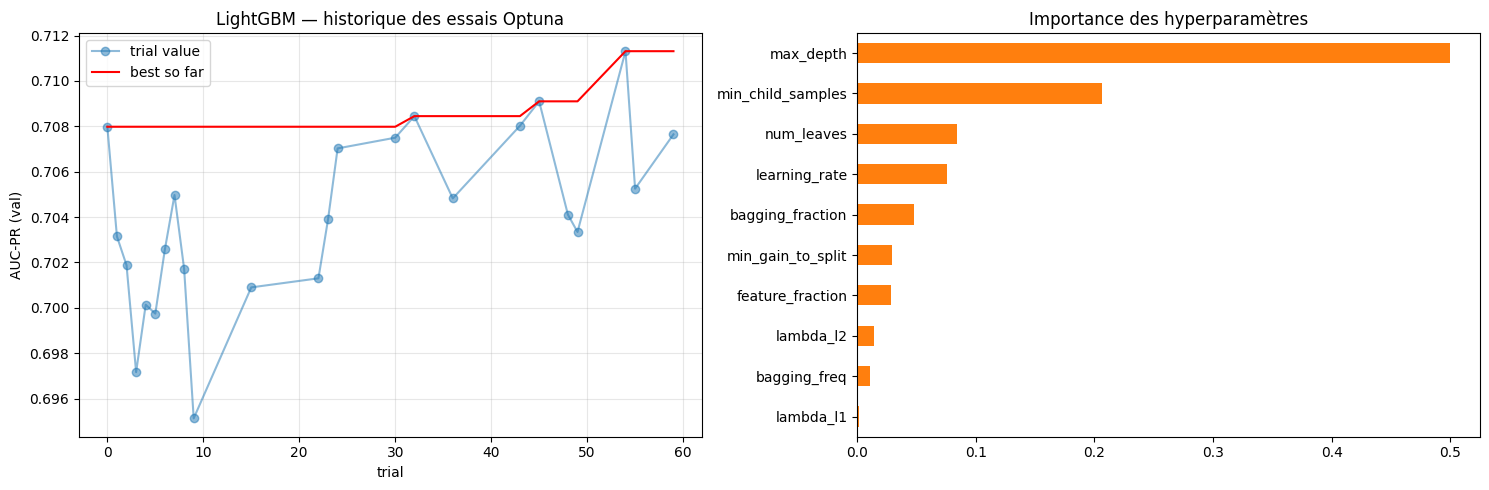

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Historique des essais
ok = trials_df[trials_df.state == 'COMPLETE']
axes[0].plot(ok.number, ok.value, 'o-', alpha=0.5, label='trial value')
axes[0].plot(ok.number, ok.value.cummax(), 'r-', label='best so far')
axes[0].set_title('LightGBM — historique des essais Optuna')
axes[0].set_xlabel('trial'); axes[0].set_ylabel('AUC-PR (val)')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Importance des hyperparamètres
try:
    imp_lgb = optuna.importance.get_param_importances(study_lgb)
    pd.Series(imp_lgb).sort_values().plot.barh(ax=axes[1], color='C1')
    axes[1].set_title('Importance des hyperparamètres')
except Exception as e:
    axes[1].text(0.5, 0.5, f'N/A: {e}', ha='center')

plt.tight_layout()
optuna_png = f'{OUT_DIR}/optuna_study.png'
plt.savefig(optuna_png, dpi=120, bbox_inches='tight')
plt.show()
mlflow.log_artifact(optuna_png)

## 12. Entraînement final LightGBM avec hyperparamètres optimisés

Les meilleurs paramètres Optuna sont utilisés pour un training final avec `early_stopping=150` (plus permissif que pendant l'étude pour garantir convergence complète).

In [16]:
def auc_pr_lgb(y_pred, dataset):
    return 'auc_pr', average_precision_score(dataset.get_label(), y_pred), True

lgb_params = {
    'objective': 'binary',
    'metric': 'None',
    'is_unbalance': True,
    'verbose': -1,
    **study_lgb.best_params,
}

mlflow.log_params(lgb_params)
mlflow.log_params({
    'num_boost_round_final': 3000,
    'early_stopping_final' : 150,
})

dtr = lgb.Dataset(X_tr,  y_tr)
dvl = lgb.Dataset(X_val, y_val)

with timed_stage('train_lgbm_final'):
    model_lgb = lgb.train(
        lgb_params, dtr, num_boost_round=3000,
        valid_sets=[dvl], feval=auc_pr_lgb,
        callbacks=[lgb.early_stopping(150), lgb.log_evaluation(200)],
    )

with timed_stage('inference_val'):
    pred_lgb_val = model_lgb.predict(X_val)

with timed_stage('inference_test'):
    pred_lgb_te = model_lgb.predict(X_te)

print('\nLightGBM (Optuna-tuned) :')
auc_roc_val, auc_pr_val = evaluate(y_val, pred_lgb_val, 'LightGBM', 'val')
auc_roc_te,  auc_pr_te  = evaluate(y_te,  pred_lgb_te,  'LightGBM', 'test')

# Récupération des metrics complètes
last_val = next(r for r in reversed(results) if r['split'] == 'val')
last_te  = next(r for r in reversed(results) if r['split'] == 'test')

mlflow.log_metrics({
    'val_auc_roc'    : auc_roc_val,
    'val_auc_pr'     : auc_pr_val,
    'val_f1_0.5'     : last_val['f1_0.5'],
    'val_recall_0.5' : last_val['recall_0.5'],
    'val_f1_opt'     : last_val['f1_opt'],
    'val_recall_opt' : last_val['recall_opt'],
    'val_threshold_opt': last_val['threshold_opt'],
    'test_auc_roc'   : auc_roc_te,
    'test_auc_pr'    : auc_pr_te,
    'test_f1_0.5'    : last_te['f1_0.5'],
    'test_recall_0.5': last_te['recall_0.5'],
    'test_f1_opt'    : last_te['f1_opt'],
    'test_recall_opt': last_te['recall_opt'],
    'test_threshold_opt': last_te['threshold_opt'],
    'best_iteration' : model_lgb.best_iteration,
})

mlflow.lightgbm.log_model(model_lgb, artifact_path='model_holdout')
print(f'\nBest iteration final : {model_lgb.best_iteration}')

[train_lgbm_final] start ... (RAM : 13.46 GB)
Training until validation scores don't improve for 150 rounds
[200]	valid_0's auc_pr: 0.653073
[400]	valid_0's auc_pr: 0.680951
[600]	valid_0's auc_pr: 0.691895
[800]	valid_0's auc_pr: 0.698526
[1000]	valid_0's auc_pr: 0.703325
[1200]	valid_0's auc_pr: 0.705913
[1400]	valid_0's auc_pr: 0.708804
[1600]	valid_0's auc_pr: 0.710225
[1800]	valid_0's auc_pr: 0.710906
[2000]	valid_0's auc_pr: 0.711312
[2200]	valid_0's auc_pr: 0.711566
[2400]	valid_0's auc_pr: 0.711534
Early stopping, best iteration is:
[2278]	valid_0's auc_pr: 0.711751
[train_lgbm_final] done in 762.0s (RAM : 13.46 GB, Δ +0.00 GB)
[inference_val] start ... (RAM : 13.46 GB)
[inference_val] done in 41.3s (RAM : 13.46 GB, Δ +0.00 GB)
[inference_test] start ... (RAM : 13.46 GB)
[inference_test] done in 36.0s (RAM : 13.46 GB, Δ +0.00 GB)

LightGBM (Optuna-tuned) :
  val   | AUC-ROC: 0.9484 | AUC-PR: 0.7118 | F1@0.5: 0.6462 | Rec@0.5: 0.5112 | F1*: 0.6885 (th=0.064) | Rec*: 0.6480


2026/05/19 03:10:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


  test  | AUC-ROC: 0.9140 | AUC-PR: 0.5779 | F1@0.5: 0.5438 | Rec@0.5: 0.4124 | F1*: 0.5665 (th=0.132) | Rec*: 0.4934

Best iteration final : 2278


## 13. Courbes ROC et PR (test hold-out)

  test  | AUC-ROC: 0.9140 | AUC-PR: 0.5779 | F1@0.5: 0.5438 | Rec@0.5: 0.4124 | F1*: 0.5665 (th=0.132) | Rec*: 0.4934


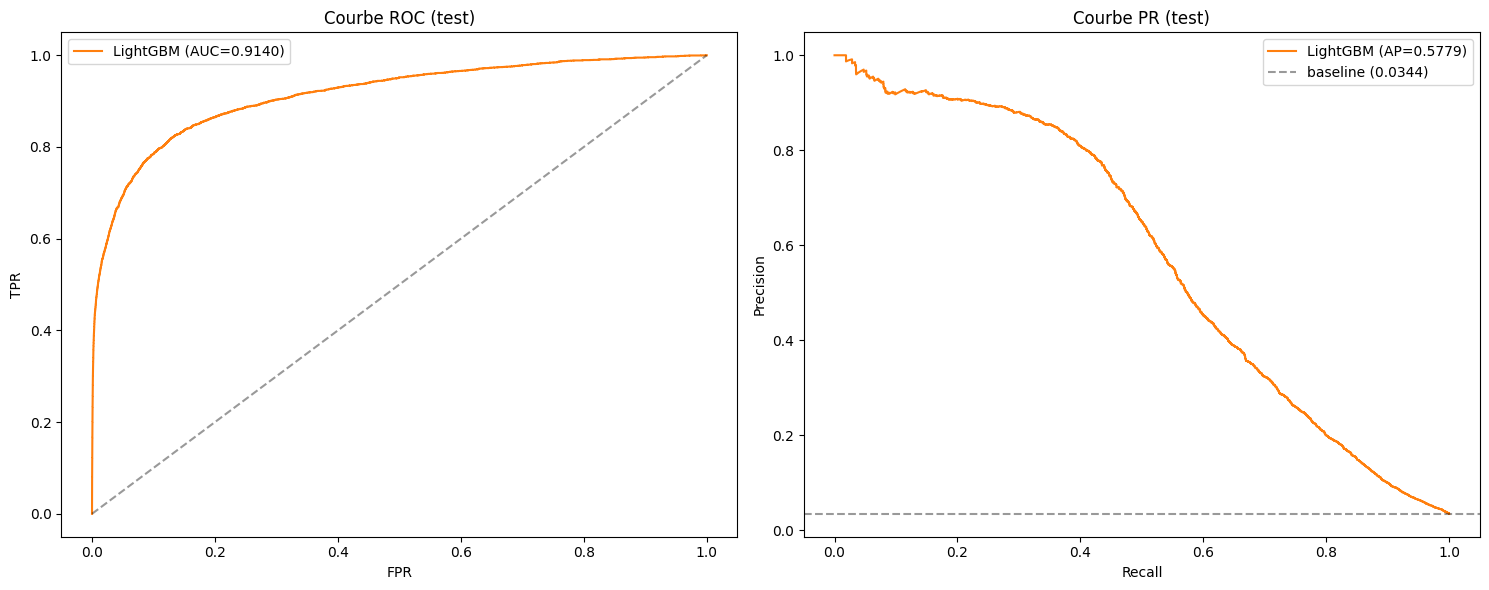

auc_pr         auc_roc          f1_0.5          f1_opt          \
split       test     val    test     val    test     val    test     val   
model                                                                      
LightGBM  0.5779  0.7118   0.914  0.9484  0.5438  0.6462  0.5665  0.6885   

         recall_0.5         recall_opt         
split          test     val       test    val  
model                                          
LightGBM     0.4124  0.5112     0.4934  0.648

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
evaluate(y_te, pred_lgb_te, 'LightGBM', 'test', ax1, ax2, 'C1')

ax1.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax1.set_xlabel('FPR'); ax1.set_ylabel('TPR')
ax1.set_title('Courbe ROC (test)'); ax1.legend()

ax2.axhline(y_te.mean(), color='k', ls='--', alpha=0.4, label=f'baseline ({y_te.mean():.4f})')
ax2.set_xlabel('Recall'); ax2.set_ylabel('Precision')
ax2.set_title('Courbe PR (test)'); ax2.legend()

plt.tight_layout()
curves_path = f'{OUT_DIR}/curves_lgbm_optuna.png'
plt.savefig(curves_path, dpi=120, bbox_inches='tight')
plt.show()
mlflow.log_artifact(curves_path)

results_df = pd.DataFrame(results)
results_df.pivot_table(
    index='model', columns='split',
    values=['auc_roc', 'auc_pr', 'f1_0.5', 'recall_0.5', 'f1_opt', 'recall_opt'],
).round(4)

## 14. Feature importance (top 30, gain)

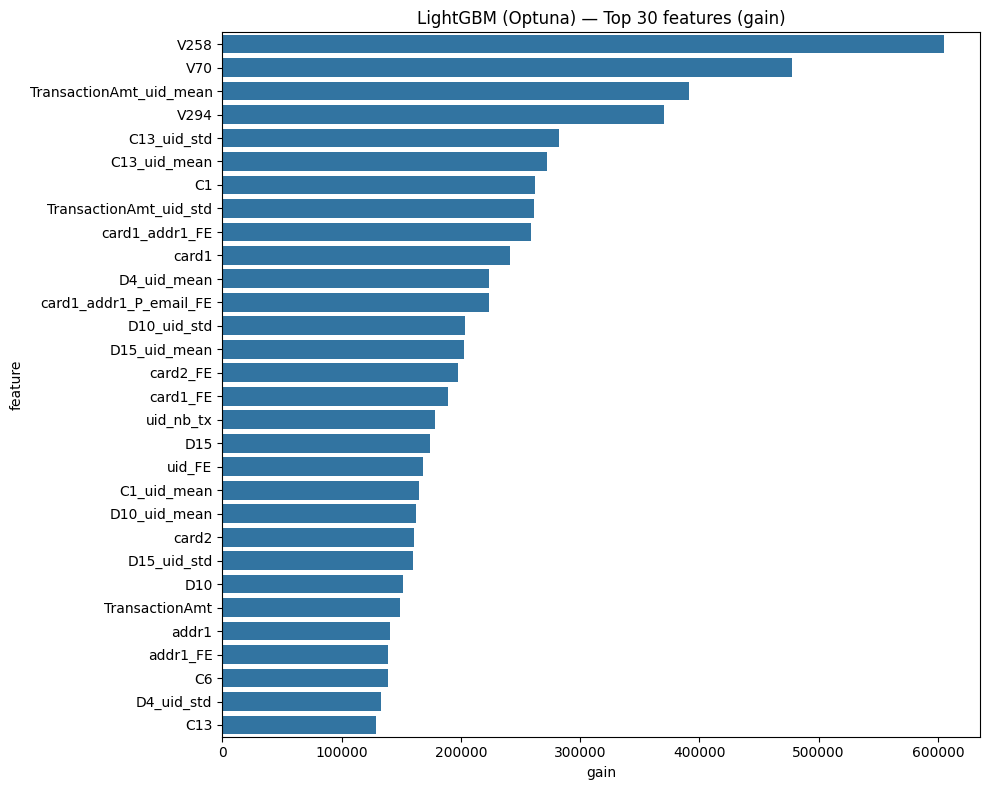

Features UID/magic dans le top 30 : 18/30


In [18]:
imp = pd.DataFrame({
    'feature': FEATURES,
    'gain'   : model_lgb.feature_importance(importance_type='gain'),
    'split'  : model_lgb.feature_importance(importance_type='split'),
}).sort_values('gain', ascending=False)

top30 = imp.head(30)

plt.figure(figsize=(10, 8))
sns.barplot(data=top30, y='feature', x='gain')
plt.title('LightGBM (Optuna) — Top 30 features (gain)')
plt.tight_layout()
fi_png = f'{OUT_DIR}/feature_importance_lgbm_optuna.png'
plt.savefig(fi_png, dpi=120, bbox_inches='tight')
plt.show()

fi_csv = f'{OUT_DIR}/feature_importance_lgbm_optuna.csv'
imp.to_csv(fi_csv, index=False)
mlflow.log_artifact(fi_csv)
mlflow.log_artifact(fi_png)

magic_mask = top30.feature.str.contains(
    'uid|zscore|ratio|_FE|_diff|time_delta|outsider|nb_tx|nb_cards', regex=True
)
print(f'Features UID/magic dans le top 30 : {magic_mask.sum()}/30')

## 15. Réentraînement sur 100 % des données labellisées

In [19]:
X_full = pd.concat([X_tr, X_val, X_te], ignore_index=True)
y_full = pd.concat([y_tr, y_val, y_te], ignore_index=True)
dfull  = lgb.Dataset(X_full, y_full)

with timed_stage('refit_full'):
    model_lgb_full = lgb.train(lgb_params, dfull, num_boost_round=model_lgb.best_iteration)

print(f'Réentraîné sur {len(X_full):,} lignes × {model_lgb.best_iteration} rounds')

mlflow.log_params({'n_full': len(X_full)})
mlflow.lightgbm.log_model(model_lgb_full, artifact_path='model_full')

[refit_full] start ... (RAM : 15.01 GB)


2026/05/19 03:28:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


[refit_full] done in 1076.4s (RAM : 15.73 GB, Δ +0.72 GB)
Réentraîné sur 590,540 lignes × 2278 rounds


## 16. Soumission Kaggle

In [20]:
X_kaggle = test_kaggle[FEATURES]

with timed_stage('inference_kaggle'):
    sub = pd.DataFrame({
        'TransactionID': test_kaggle['TransactionID'],
        'isFraud'      : model_lgb_full.predict(X_kaggle),
    })

sub_path = f'{OUT_DIR}/submission_lgbm_optuna_centralized.csv'
sub.to_csv(sub_path, index=False)

print('=== Soumission LightGBM Optuna centralisé ===')
print(sub.isFraud.describe().round(4))
mlflow.log_artifact(sub_path)

[inference_kaggle] start ... (RAM : 16.95 GB)
[inference_kaggle] done in 202.1s (RAM : 16.95 GB, Δ +0.00 GB)
=== Soumission LightGBM Optuna centralisé ===
count    506691.0000
mean          0.0223
std           0.1346
min           0.0000
25%           0.0000
50%           0.0000
75%           0.0003
max           1.0000
Name: isFraud, dtype: float64


## 17. Récap des timings + fermeture du run

In [21]:
log_memory('end')

time_pipeline_total_s = sum(TIMINGS.values())
mlflow.log_metric('time_pipeline_total_s', time_pipeline_total_s)

peak_mem_gb = max(MEMORY.values())
mlflow.log_metric('mem_peak_gb', peak_mem_gb)

print('=' * 60)
print('RÉCAP TIMINGS (centralisé Optuna)')
print('=' * 60)
for stage, t in TIMINGS.items():
    pct = 100 * t / time_pipeline_total_s
    print(f'  {stage:25s} : {t:7.1f}s  ({pct:5.1f}%)')
print('-' * 60)
print(f'  {"TOTAL":25s} : {time_pipeline_total_s:7.1f}s  (100.0%)')
print()
print(f'Peak RAM observée : {peak_mem_gb:.2f} GB')
print(f'Run ID            : {RUN_ID}')

RÉCAP TIMINGS (centralisé Optuna)
  load_merge                :    52.4s  (  0.3%)
  drop_columns              :     7.4s  (  0.0%)
  fe_common                 :    27.5s  (  0.1%)
  fe_advanced               :    68.9s  (  0.4%)
  label_encoding            :    27.0s  (  0.1%)
  impute_split              :    12.9s  (  0.1%)
  optuna_study              : 17311.8s  ( 88.2%)
  train_lgbm_final          :   762.0s  (  3.9%)
  inference_val             :    41.3s  (  0.2%)
  inference_test            :    36.0s  (  0.2%)
  refit_full                :  1076.4s  (  5.5%)
  inference_kaggle          :   202.1s  (  1.0%)
------------------------------------------------------------
  TOTAL                     : 19625.9s  (100.0%)

Peak RAM observée : 16.95 GB
Run ID            : 21494a26a8ae49d1a03f852c697b15b6


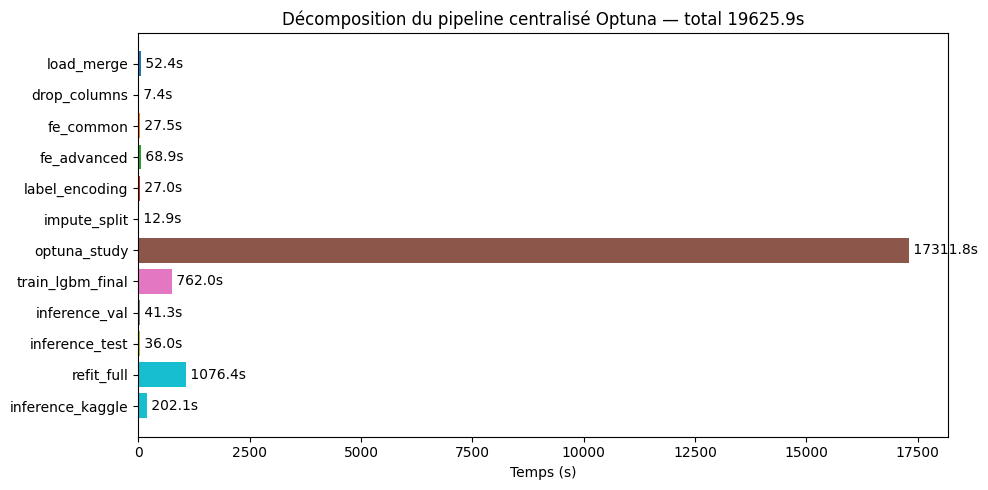

In [22]:
# Bar chart des timings
fig, ax = plt.subplots(figsize=(10, 5))
stages = list(TIMINGS.keys())
times  = [TIMINGS[s] for s in stages]
colors = plt.cm.tab10(np.linspace(0, 1, len(stages)))
ax.barh(stages, times, color=colors)
for i, t in enumerate(times):
    ax.text(t, i, f' {t:.1f}s', va='center')
ax.set_xlabel('Temps (s)')
ax.set_title(f'Décomposition du pipeline centralisé Optuna — total {time_pipeline_total_s:.1f}s')
ax.invert_yaxis()
plt.tight_layout()
timings_png = f'{OUT_DIR}/timings_breakdown_optuna.png'
plt.savefig(timings_png, dpi=120, bbox_inches='tight')
plt.show()
mlflow.log_artifact(timings_png)

In [23]:
# Fermeture explicite du run
mlflow.end_run()
print('Run MLflow fermé.')

# Zip du dossier mlruns pour téléchargement et upload vers GCS pour la comparaison
import shutil
zip_path = shutil.make_archive(f'{OUT_DIR}/mlruns_centralized_optuna', 'zip', MLFLOW_DIR)
print(f'MLflow runs zippés : {zip_path}')
print(f'Taille : {os.path.getsize(zip_path) / 1024:.0f} KB')
print()
print('Pour la comparaison avec la version distribuée :')
print('1. Télécharger ce zip depuis les outputs Kaggle')
print('2. L\'uploader sur le bucket GCS utilisé par le notebook Dataproc')
print('3. Le notebook Dataproc l\'extraira et combinera les runs pour la comparaison finale')

Run MLflow fermé.
MLflow runs zippés : /kaggle/working/mlruns_centralized_optuna.zip
Taille : 112652 KB

Pour la comparaison avec la version distribuée :
1. Télécharger ce zip depuis les outputs Kaggle
2. L'uploader sur le bucket GCS utilisé par le notebook Dataproc
3. Le notebook Dataproc l'extraira et combinera les runs pour la comparaison finale
